Install & Imports

In [ ]:
# Install Gradio for nice interactive UI
!pip install gradio -q

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import gradio as gr
from google.colab import files
import os

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Load & Preprocess MNIST

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Reshape
x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)

# One-hot encode
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

print("Training samples:", x_train.shape[0])
print("Test samples:", x_test.shape[0])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 60000
Test samples: 10000


Improved Model

In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 872,042 (3.33 MB)

 Trainable params: 871,338 (3.32 MB)

 Non-trainable params: 704 (2.75 KB)

Data Augmentation + Training

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=12,
    zoom_range=0.12,
    width_shift_range=0.12,
    height_shift_range=0.12
)

early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

print("Training improved model...")
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=128),
    epochs=20,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Training improved model...
Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 38s 60ms/step - accuracy: 0.8833 - loss: 0.3837 - val_accuracy: 0.4140 - val_loss: 1.5337 - learning_rate: 0.0010
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.9658 - loss: 0.1120 - val_accuracy: 0.9867 - val_loss: 0.0404 - learning_rate: 0.0010
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.9747 - loss: 0.0831 - val_accuracy: 0.9919 - val_loss: 0.0264 - learning_rate: 0.0010
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - accuracy: 0.9793 - loss: 0.0688 - val_accuracy: 0.9879 - val_loss: 0.0389 - learning_rate: 0.0010
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.9804 - loss: 0.0624 - val_accuracy: 0.9916 - val_loss: 0.0247 - learning_rate: 0.0010
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.9813 - loss: 0.0602 - val_accuracy: 0.9906 - val_loss: 0.0273 - learning_rate: 0.0010
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/

Evaluate & Save

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

model.save("improved_digit_model.h5")
print("Model saved as 'improved_digit_model.h5'")


Test Accuracy: 99.70%
Model saved as 'improved_digit_model.h5'


Robust Preprocessing Function

In [ ]:
def preprocess_digit(img, show=False):
    """
    Robust preprocessing for real handwritten digits.
    Accepts PIL Image or file path.
    """
    if isinstance(img, str):
        img = Image.open(img)

    # Convert to grayscale
    img = img.convert('L')
    img_array = np.array(img)

    # Auto-invert if background is dark
    if np.mean(img_array) < 127:
        img_array = 255 - img_array

    # Threshold
    _, img_array = cv2.threshold(img_array, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Find digit and crop
    coords = cv2.findNonZero(255 - img_array)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        img_array = img_array[y:y+h, x:x+w]

    # Resize to 20x20 then pad to 28x28 (MNIST style)
    img_array = cv2.resize(img_array, (20, 20), interpolation=cv2.INTER_AREA)
    img_array = np.pad(img_array, ((4, 4), (4, 4)), mode='constant', constant_values=255)

    # Normalize + invert (MNIST is white digit on black)
    img_array = img_array.astype("float32") / 255.0
    img_array = 1.0 - img_array

    if show:
        plt.figure(figsize=(3,3))
        plt.imshow(img_array, cmap='gray')
        plt.title("Preprocessed")
        plt.axis('off')
        plt.show()

    return img_array.reshape(1, 28, 28, 1)

Quick Test with Upload

Saving images.jpg to images.jpg


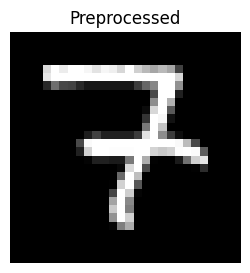


Predicted Digit : 7
Confidence      : 100.00%

All probabilities:
  0 →   0.0%
  1 →   0.0%
  2 →   0.0%
  3 →   0.0%
  4 →   0.0%
  5 →   0.0%
  6 →   0.0%
  7 → 100.0%
  8 →   0.0%
  9 →   0.0%


In [ ]:
# Optional: Upload a test image and predict
uploaded = files.upload()

if uploaded:
    image_path = list(uploaded.keys())[0]
    processed = preprocess_digit(image_path, show=True)

    preds = model.predict(processed, verbose=0)[0]
    digit = np.argmax(preds)
    conf  = preds[digit] * 100

    print(f"\nPredicted Digit : {digit}")
    print(f"Confidence      : {conf:.2f}%")
    print("\nAll probabilities:")
    for i, p in enumerate(preds):
        print(f"  {i} → {p*100:5.1f}%")

Beautiful Gradio Interface

In [ ]:
def predict_digit(img):
    if img is None:
        return None

    processed = preprocess_digit(img, show=False)
    preds = model.predict(processed, verbose=0)[0]

    # Return dictionary for Gradio Label
    return {str(i): float(preds[i]) for i in range(10)}

iface = gr.Interface(
    fn=predict_digit,
    inputs=gr.Image(type="pil", label="Upload Photo or Draw Digit", sources=["upload", "webcam", "clipboard"]),
    outputs=gr.Label(num_top_classes=3, label="Prediction"),
    title="Improved Handwritten Digit Recognizer",
    description="Upload a clear photo of a digit (0-9) or draw one. The model will predict it instantly with confidence scores.",
    examples=None,
    theme=gr.themes.Soft()
)

iface.launch(share=True, debug=True)

/usr/local/lib/python3.13/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://f644ad9cc1128a1212.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Created dataset file at: .gradio/flagged/dataset1.csv
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://f644ad9cc1128a1212.gradio.live
